In [ ]:
import pandas as pd
import numpy as np
import sklearn
import seaborn as sns
import yellowbrick

In [ ]:
dados = pd.read_csv('/content/flights.csv')

In [ ]:
dados.head()

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay
0,26,MM,Airbus A320,non-schengen,TCY,8.885071,10.885071,0,2010,False,70.205981
1,10,YE,Airbus A320,non-schengen,TCY,8.939996,11.939996,0,2010,False,38.484609
2,3,BZ,Embraer E175,schengen,TZF,18.635384,22.635384,0,2010,False,2.388305
3,28,BZ,Airbus A330,non-schengen,EMM,15.967963,17.967963,0,2010,False,19.138491
4,15,BZ,Airbus A330,non-schengen,FJB,16.571894,19.571894,0,2010,False,15.016271


In [ ]:
dados.tail()

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay
71170,3,BZ,Embraer E175,schengen,TZF,18.635384,22.635384,364,2022,True,25.677277
71171,17,BZ,Airbus A330,non-schengen,CNU,16.718722,21.718722,364,2022,True,52.624348
71172,7,MM,Boeing 787,schengen,TZF,8.564949,13.564949,364,2022,True,56.167080
71173,5,BZ,Airbus A320,schengen,ZQO,9.344097,12.344097,364,2022,True,56.758844
71174,29,BZ,Boeing 737,schengen,ZQO,8.591208,11.591208,364,2022,True,41.401648


In [ ]:
dados.shape

(71175, 11)

In [ ]:
#Exibindo colunas numericas
dados.describe()

,flight_id,arrival_time,departure_time,day,year,delay
count,71175.000000,71175.000000,71175.000000,71175.000000,71175.000000,71175.000000
mean,15.465135,13.283159,16.480222,182.000000,2016.000000,12.548378
std,8.649646,4.023380,4.143705,105.366769,3.741684,23.125349
min,1.000000,7.065594,10.065594,0.000000,2010.000000,-41.028033
25%,8.000000,8.939996,12.668655,91.000000,2013.000000,-4.412876
50%,15.000000,14.258911,16.376052,182.000000,2016.000000,9.740454
75%,23.000000,16.909690,20.041281,273.000000,2019.000000,27.650853
max,30.000000,19.341235,23.341235,364.000000,2022.000000,125.632352


In [ ]:
#Exibindo colunas categoricas
dados.describe(include = 'O')

,airline,aircraft_type,schengen,origin
count,71175,71175,71175,71175
unique,3,6,2,10
top,BZ,Airbus A320,schengen,TZF
freq,47598,30778,42569,14162


In [ ]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71175 entries, 0 to 71174
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   flight_id       71175 non-null  int64  
 1   airline         71175 non-null  object 
 2   aircraft_type   71175 non-null  object 
 3   schengen        71175 non-null  object 
 4   origin          71175 non-null  object 
 5   arrival_time    71175 non-null  float64
 6   departure_time  71175 non-null  float64
 7   day             71175 non-null  int64  
 8   year            71175 non-null  int64  
 9   is_holiday      71175 non-null  bool   
 10  delay           71175 non-null  float64
dtypes: bool(1), float64(3), int64(3), object(4)
memory usage: 5.5+ MB


# Visualização de gráficos dos dados

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
average_delay = dados.groupby('airline')['delay'].mean().reset_index()
average_delay

,airline,delay
0,BZ,3.077595
1,MM,40.498007
2,YE,25.772248


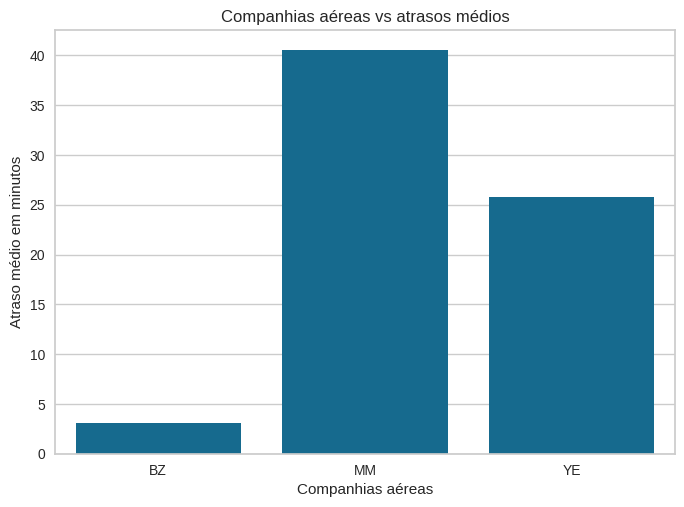

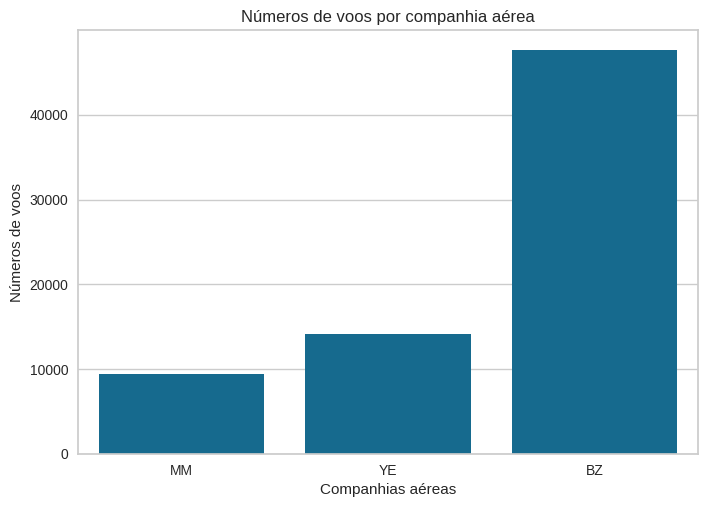

In [ ]:

sns.barplot(x = 'airline', y = 'delay', data = average_delay)
plt.title('Companhias aéreas vs atrasos médios')
plt.xlabel('Companhias aéreas')
plt.ylabel('Atraso médio em minutos')
plt.show()

sns.countplot(data = dados, x = 'airline')
plt.title('Números de voos por companhia aérea')
plt.xlabel('Companhias aéreas')
plt.ylabel('Números de voos')
plt.show()

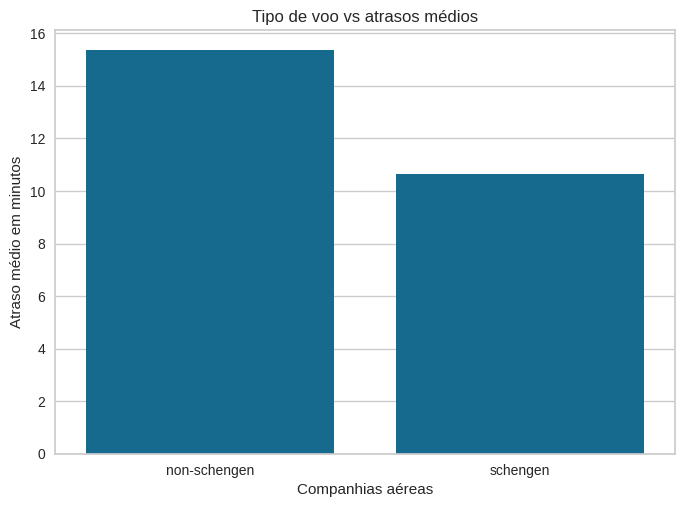

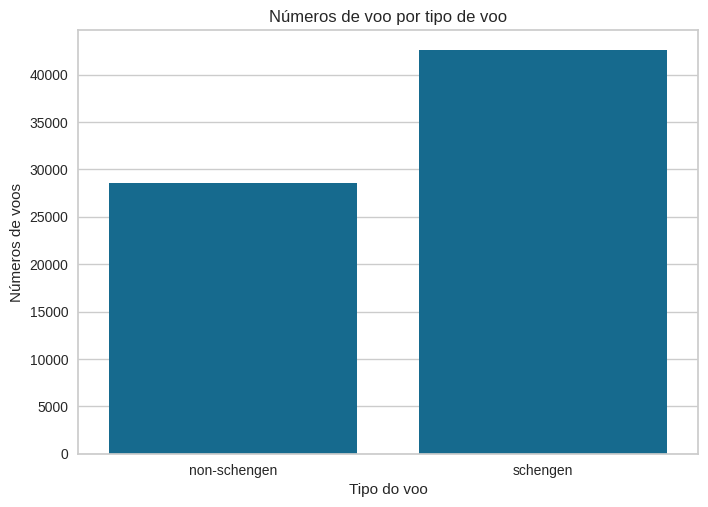

In [ ]:
average_delay = dados.groupby('schengen')['delay'].mean().reset_index()
sns.barplot(x = 'schengen', y = 'delay', data = average_delay)
plt.title('Tipo de voo vs atrasos médios')
plt.xlabel('Companhias aéreas')
plt.ylabel('Atraso médio em minutos')
plt.show()

sns.countplot(data = dados, x = 'schengen')
plt.title('Números de voo por tipo de voo')
plt.xlabel('Tipo do voo')
plt.ylabel('Números de voos')
plt.show()

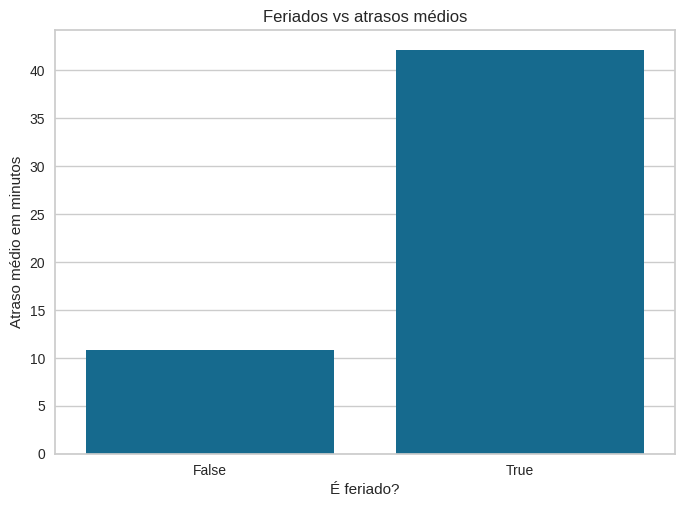

In [ ]:
average_delay = dados.groupby('is_holiday')['delay'].mean().reset_index()
sns.barplot(x = 'is_holiday', y = 'delay', data = average_delay)
plt.title('Feriados vs atrasos médios')
plt.xlabel('É feriado?')
plt.ylabel('Atraso médio em minutos')
plt.show()

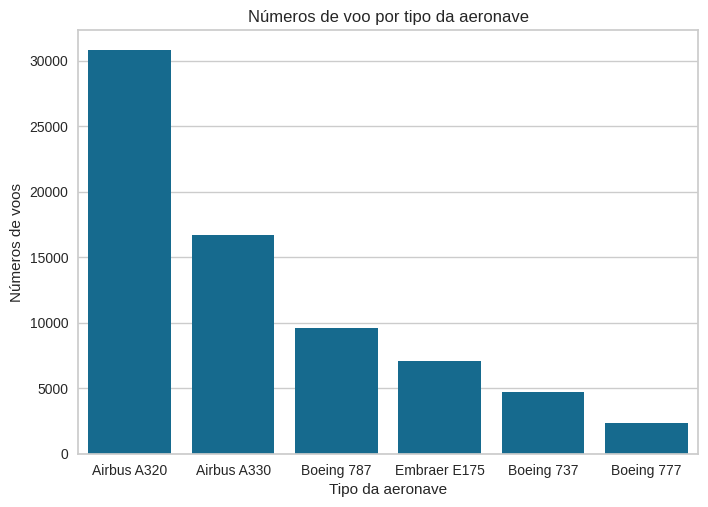

In [ ]:
order = dados['aircraft_type'].value_counts().index
sns.countplot(data = dados, x = 'aircraft_type', order = order)
plt.title('Números de voo por tipo da aeronave')
plt.xlabel('Tipo da aeronave')
plt.ylabel('Números de voos')
plt.show()

# Analisando a distribuição dos dados

In [ ]:
def calcular_largura_bin(df, coluna):
  Q75, Q25 = np.percentile(df[coluna], [75, 25])
  IQR = Q75 - Q25
  largura_bin = 2 * IQR * np.power(len(df[coluna]), -1/3)
  return largura_bin

<Axes: xlabel='arrival_time', ylabel='Count'>

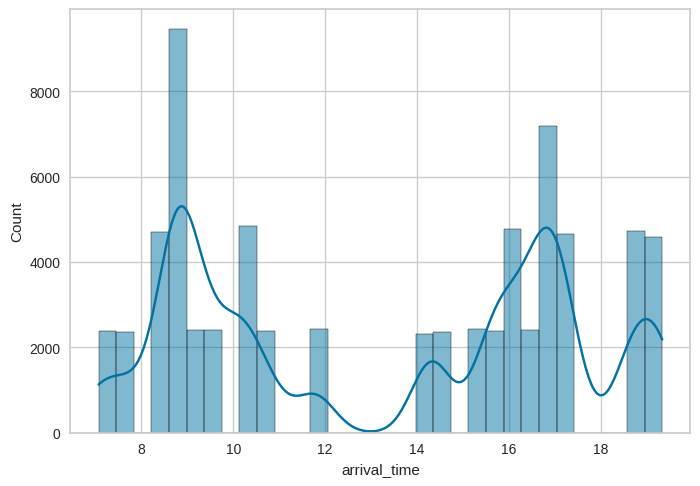

In [ ]:

largura_bin_dt = calcular_largura_bin(dados, 'arrival_time')
sns.histplot(data = dados, x = 'arrival_time',kde = True, binwidth = largura_bin_dt)

<Axes: xlabel='departure_time', ylabel='Count'>

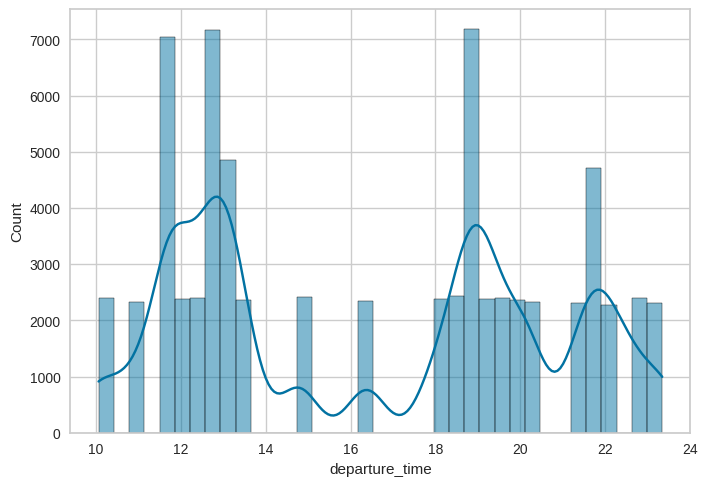

In [ ]:
largura_bin_at = calcular_largura_bin(dados, 'departure_time')
sns.histplot(data = dados, x = 'departure_time',kde = True, binwidth = largura_bin_at)

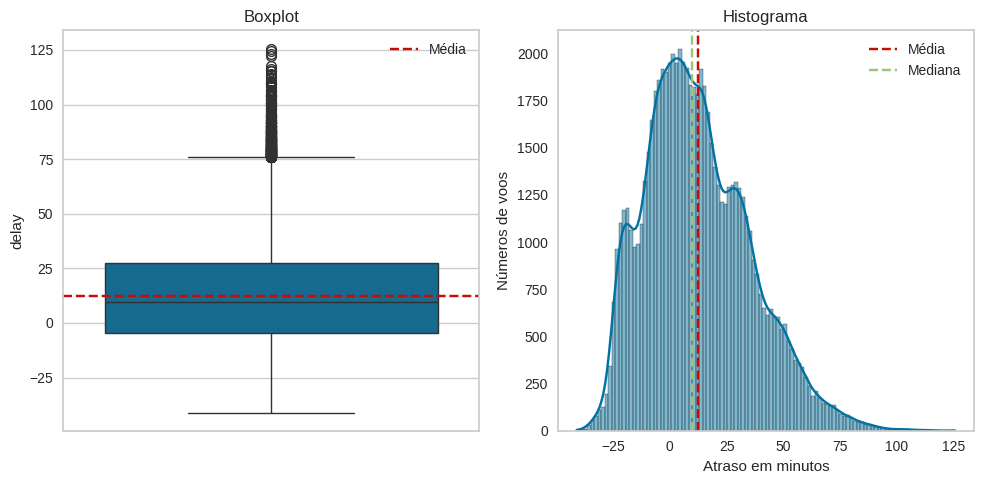

In [ ]:
mean_delay = dados['delay'].mean()
median_delay = dados['delay'].median()

fig, axes = plt.subplots(1, 2, figsize = (10, 5))

sns.boxplot(data = dados, y = 'delay', ax = axes[0])
axes[0].set_title('Boxplot')

axes[0].axhline(y = mean_delay, color = 'r', linestyle = '--', label = 'Média')
axes[0].legend()

largura_bin_dt = calcular_largura_bin(dados, 'delay')
sns.histplot(data = dados, x = 'delay', ax = axes[1], kde = True, binwidth = largura_bin_dt)
plt.xlabel('Atraso em minutos')
plt.ylabel('Números de voos')
plt.grid(False)
axes[1].set_title('Histograma')

axes[1].axvline(x = mean_delay, color = 'r', linestyle = '--', label = 'Média')
axes[1].axvline(x = median_delay, color = 'g', linestyle = '--', label = 'Mediana')
axes[1].legend()

plt.tight_layout()
plt.show()


# Feature engineering

In [ ]:
dados.head(1)

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay
0,26,MM,Airbus A320,non-schengen,TCY,8.885071,10.885071,0,2010,False,70.205981


In [ ]:
#Convertendo o formato de data e criando uma nova coluna nno dataframe
dados['date'] = pd.to_datetime(dados['year'].astype(str) + '-' +  (dados['day'] + 1).astype(str),format = '%Y-%j')
dados.head()

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay,date
0,26,MM,Airbus A320,non-schengen,TCY,8.885071,10.885071,0,2010,False,70.205981,2010-01-01
1,10,YE,Airbus A320,non-schengen,TCY,8.939996,11.939996,0,2010,False,38.484609,2010-01-01
2,3,BZ,Embraer E175,schengen,TZF,18.635384,22.635384,0,2010,False,2.388305,2010-01-01
3,28,BZ,Airbus A330,non-schengen,EMM,15.967963,17.967963,0,2010,False,19.138491,2010-01-01
4,15,BZ,Airbus A330,non-schengen,FJB,16.571894,19.571894,0,2010,False,15.016271,2010-01-01


In [ ]:
#É um final de semana ou não
dados['is_weekend'] = dados['date'].dt.weekday.isin([5, 6])

In [ ]:
#Adicionando os nomes das semanas
dados['day_name'] = dados['date'].dt.day_name()

In [ ]:
dados.head()

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay,date,is_weekend,day_name
0,26,MM,Airbus A320,non-schengen,TCY,8.885071,10.885071,0,2010,False,70.205981,2010-01-01,False,Friday
1,10,YE,Airbus A320,non-schengen,TCY,8.939996,11.939996,0,2010,False,38.484609,2010-01-01,False,Friday
2,3,BZ,Embraer E175,schengen,TZF,18.635384,22.635384,0,2010,False,2.388305,2010-01-01,False,Friday
3,28,BZ,Airbus A330,non-schengen,EMM,15.967963,17.967963,0,2010,False,19.138491,2010-01-01,False,Friday
4,15,BZ,Airbus A330,non-schengen,FJB,16.571894,19.571894,0,2010,False,15.016271,2010-01-01,False,Friday


# Feature Encoding

In [ ]:
dados.nunique()

,0
flight_id,30
airline,3
aircraft_type,6
schengen,2
origin,10
arrival_time,30
departure_time,30
day,365
year,13
is_holiday,2


In [ ]:
dados['is_holiday'].unique()

array([False,  True])

In [ ]:
dados['schengen'] = dados['schengen'].replace({'non-schengen': 0, 'schengen': 1})
dados['is_holiday'] = dados['is_holiday'].replace({'False': 0, 'True': 1})
dados['is_weekend'] = dados['is_weekend'].replace({'False': 0, 'True': 1})
dados.head()

/tmp/ipython-input-3343808494.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dados['schengen'] = dados['schengen'].replace({'non-schengen': 0, 'schengen': 1})


,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay,date,is_weekend,day_name
0,26,MM,Airbus A320,0,TCY,8.885071,10.885071,0,2010,False,70.205981,2010-01-01,False,Friday
1,10,YE,Airbus A320,0,TCY,8.939996,11.939996,0,2010,False,38.484609,2010-01-01,False,Friday
2,3,BZ,Embraer E175,1,TZF,18.635384,22.635384,0,2010,False,2.388305,2010-01-01,False,Friday
3,28,BZ,Airbus A330,0,EMM,15.967963,17.967963,0,2010,False,19.138491,2010-01-01,False,Friday
4,15,BZ,Airbus A330,0,FJB,16.571894,19.571894,0,2010,False,15.016271,2010-01-01,False,Friday


In [ ]:
variaveis_categoricas = ['airline', 'aircraft_type', 'origin', 'day_name']

In [ ]:
df_encoded = pd.get_dummies(data = dados, columns = variaveis_categoricas, dtype = int)
df_encoded.head()

,flight_id,schengen,arrival_time,departure_time,day,year,is_holiday,delay,date,is_weekend,...,origin_TCY,origin_TZF,origin_ZQO,day_name_Friday,day_name_Monday,day_name_Saturday,day_name_Sunday,day_name_Thursday,day_name_Tuesday,day_name_Wednesday
0,26,0,8.885071,10.885071,0,2010,False,70.205981,2010-01-01,False,...,1,0,0,1,0,0,0,0,0,0
1,10,0,8.939996,11.939996,0,2010,False,38.484609,2010-01-01,False,...,1,0,0,1,0,0,0,0,0,0
2,3,1,18.635384,22.635384,0,2010,False,2.388305,2010-01-01,False,...,0,1,0,1,0,0,0,0,0,0
3,28,0,15.967963,17.967963,0,2010,False,19.138491,2010-01-01,False,...,0,0,0,1,0,0,0,0,0,0
4,15,0,16.571894,19.571894,0,2010,False,15.016271,2010-01-01,False,...,0,0,0,1,0,0,0,0,0,0


# Limpando os dados

In [ ]:
df_encoded[['arrival_time', 'departure_time']].corr()

,arrival_time,departure_time
arrival_time,1.000000,0.973797
departure_time,0.973797,1.000000


In [ ]:
#Removendo colunas
df_clean = df_encoded.drop(['flight_id', 'departure_time', 'day', 'year', 'date'], axis = 1)


In [ ]:
df_clean.head()

,schengen,arrival_time,is_holiday,delay,is_weekend,airline_BZ,airline_MM,airline_YE,aircraft_type_Airbus A320,aircraft_type_Airbus A330,...,origin_TCY,origin_TZF,origin_ZQO,day_name_Friday,day_name_Monday,day_name_Saturday,day_name_Sunday,day_name_Thursday,day_name_Tuesday,day_name_Wednesday
0,0,8.885071,False,70.205981,False,0,1,0,1,0,...,1,0,0,1,0,0,0,0,0,0
1,0,8.939996,False,38.484609,False,0,0,1,1,0,...,1,0,0,1,0,0,0,0,0,0
2,1,18.635384,False,2.388305,False,1,0,0,0,0,...,0,1,0,1,0,0,0,0,0,0
3,0,15.967963,False,19.138491,False,1,0,0,0,1,...,0,0,0,1,0,0,0,0,0,0
4,0,16.571894,False,15.016271,False,1,0,0,0,1,...,0,0,0,1,0,0,0,0,0,0


# Seleção e validação de modelo

# Treinamento do DummyRegresor

In [ ]:
#Variável explicativa

X = df_clean.drop(['delay'], axis = 1)

#Variavel target

y = df_clean['delay']

In [ ]:
#Separando conjunto de dados em treino e teste
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42)


In [ ]:
from sklearn.dummy import DummyRegressor

model_dummy = DummyRegressor()
model_dummy.fit(X_train, y_train)

DummyRegressor()

In [ ]:
y_pred_dummy = model_dummy.predict(X_test)


In [ ]:

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def calcular_metricas_regressao(y_test, y_pred):
  rmse = mean_squared_error(y_test, y_pred, squared = False)
  mae = mean_absolute_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)

  metricas = {
      'Raiz do erro quadratico médio': round(rmse, 4),
      'Erro absoluto médio': round(mae, 4),
      'R2 Score': round(r2, 4)

  }

  return metricas

In [ ]:
def calcular_metricas_regressao(y_test, y_pred):
  # Em versões recentes do sklearn, o parâmetro 'squared' foi removido.
  # Calculamos o MSE e tiramos a raiz quadrada manualmente para obter o RMSE.
  mse = mean_squared_error(y_test, y_pred)
  rmse = np.sqrt(mse)
  mae = mean_absolute_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)

  metricas = {
      'Raiz do erro quadratico médio': round(rmse, 4),
      'Erro absoluto médio': round(mae, 4),
      'R2 Score': round(r2, 4)
  }

  return metricas

calcular_metricas_regressao(y_test, y_pred_dummy)

{'Raiz do erro quadratico médio': np.float64(23.2241),
 'Erro absoluto médio': 18.6127,
 'R2 Score': -0.0}

# Treinamento do RandomForestRegressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(max_depth = 5, random_state = 42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
calcular_metricas_regressao(y_test, y_pred_rf)

{'Raiz do erro quadratico médio': np.float64(13.7301),
 'Erro absoluto médio': 11.0138,
 'R2 Score': 0.6505}

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


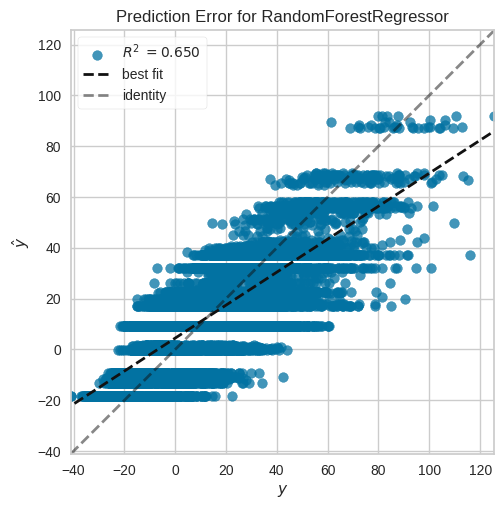

In [ ]:
from yellowbrick.regressor import prediction_error

visualizer = prediction_error(model_rf, X_train, y_train, X_test, y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


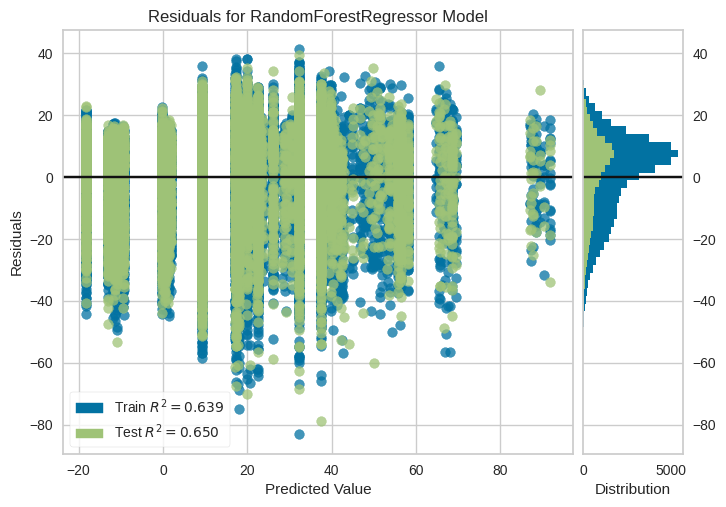

In [ ]:
from yellowbrick.regressor import residuals_plot

viz = residuals_plot(model_rf, X_train, y_train, X_test, y_test)

# Realizando validação cruzada

In [ ]:
from sklearn.model_selection import KFold, cross_validate
scoring = {
    'mae' : 'neg_mean_absolute_error',
    'rmse' : 'neg_root_mean_squared_error',
    'r2' : 'r2'
}

cv = KFold(n_splits = 5, shuffle = True, random_state = 42)
cv_results = cross_validate(model_rf, X_train, y_train, cv = cv, scoring = scoring)

In [ ]:
cv_results

{'fit_time': array([3.68855643, 3.44073677, 3.47883892, 5.08533978, 3.42483664]),
 'score_time': array([0.06521749, 0.0660665 , 0.08815885, 0.06532884, 0.06216431]),
 'test_mae': array([-11.07421449, -11.30328674, -11.05630068, -11.14454886,
        -11.17423931]),
 'test_rmse': array([-13.76668658, -14.04881475, -13.79310018, -13.87672957,
        -13.9303929 ]),
 'test_r2': array([0.64679676, 0.62433581, 0.64536956, 0.64090813, 0.63477298])}

In [ ]:
for metric in scoring.keys():
  scores = cv_results[f'test_{metric}']
  mean_score = '{:.3f}'.format(scores.mean())
  std_score = '{:.3f}'.format(scores.std())

  print(f"{metric.upper()} Scores: {[f'{val:.3f}' for val in scores]}")
  print(f"{metric.upper()} Média: {mean_score}, Std: {std_score}")
  print('-----------------------------------------------------------')

MAE Scores: ['-11.074', '-11.303', '-11.056', '-11.145', '-11.174']
MAE Média: -11.151, Std: 0.088
-----------------------------------------------------------
RMSE Scores: ['-13.767', '-14.049', '-13.793', '-13.877', '-13.930']
RMSE Média: -13.883, Std: 0.101
-----------------------------------------------------------
R2 Scores: ['0.647', '0.624', '0.645', '0.641', '0.635']
R2 Média: 0.638, Std: 0.008
-----------------------------------------------------------


# Otimização de hiperpârametros

# Seleção de recursos

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


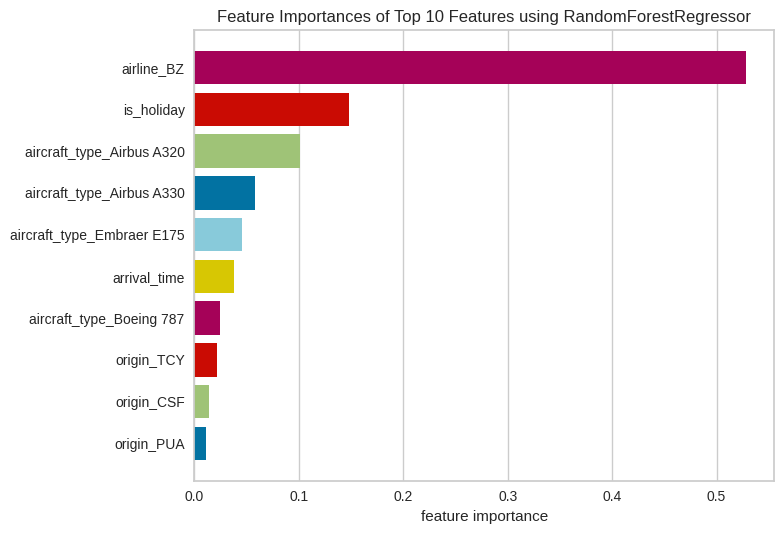

<Axes: title={'center': 'Feature Importances of Top 10 Features using RandomForestRegressor'}, xlabel='feature importance'>

In [ ]:
from yellowbrick.model_selection import FeatureImportances
viz = FeatureImportances(model_rf, relative = False, topn = 10)
viz.fit(X_train,y_train)
viz.show()

In [ ]:
importances = model_rf.feature_importances_
feature_importances = pd.DataFrame({'feature': X.columns, 'Importances': importances})
feature_importances.sort_values('Importances', ascending = False)


,feature,Importances
4,airline_BZ,0.528604
2,is_holiday,0.147833
7,aircraft_type_Airbus A320,0.100719
8,aircraft_type_Airbus A330,0.058221
12,aircraft_type_Embraer E175,0.045619
1,arrival_time,0.037614
11,aircraft_type_Boeing 787,0.024663
20,origin_TCY,0.022120
15,origin_CSF,0.013979
19,origin_PUA,0.011385


In [ ]:
results_df = pd.DataFrame(index = ['RMSE', 'MAE', 'R2'])

# Garantindo que as importâncias estejam ordenadas do maior para o menor
feature_importances_sorted = feature_importances.sort_values('Importances', ascending = False)

model_selected_features = RandomForestRegressor(random_state = 42, max_depth = 5)

for count in [1, 5, 10, 15, 20, 25, 30]:
  # Corrigido de 'Features' para 'feature'
  selected_features = feature_importances_sorted['feature'].values[:count]

  X_train_selected = X_train[selected_features]
  X_test_selected = X_test[selected_features]

  model_selected_features.fit(X_train_selected, y_train)
  y_pred = model_selected_features.predict(X_test_selected)
  metricas = calcular_metricas_regressao(y_test, y_pred)

  results_df[count] = list(metricas.values())

results_df

,1,5,10,15,20,25,30
RMSE,18.8639,15.1651,13.7426,13.7335,13.7307,13.7307,13.7301
MAE,14.9854,12.0714,11.0282,11.0164,11.0137,11.0142,11.0138
R2,0.3402,0.5736,0.6498,0.6503,0.6504,0.6504,0.6505


In [ ]:
results_df = pd.DataFrame(index = ['RMSE', 'MAE', 'R2'])
feature_importances_sorted = feature_importances.sort_values('Importances', ascending = False)

model_selected_features = RandomForestRegressor(random_state = 42, max_depth = 5)

for count in range(10, 16):
  selected_features = feature_importances_sorted['feature'].values[:count]

  X_train_selected = X_train[selected_features]
  X_test_selected = X_test[selected_features]

  model_selected_features.fit(X_train_selected, y_train)
  y_pred = model_selected_features.predict(X_test_selected)
  metricas = calcular_metricas_regressao(y_test, y_pred)

  results_df[count] = list(metricas.values())

results_df

,10,11,12,13,14,15
RMSE,13.7426,13.7378,13.7344,13.7348,13.7335,13.7335
MAE,11.0282,11.0258,11.0173,11.0177,11.0164,11.0164
R2,0.6498,0.6501,0.6503,0.6502,0.6503,0.6503


In [ ]:
selected_features = feature_importances_sorted['feature'].values[:13]
X_selected_features = X[selected_features]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_selected_features, y, random_state = 42)


# Otimizando os hiperparâmetros com o GridSearchCV

In [ ]:
param_grid = {
    'max_depth': [5, 10, 15],
    'min_samples_leaf': [1, 2, 3],
    'min_samples_split': [2, 4, 6],
    'n_estimators': [100, 150, 200]

}


In [ ]:
from sklearn.model_selection import GridSearchCV


In [ ]:
cv = KFold(n_splits = 5, shuffle = True, random_state = 42)
model_grid = GridSearchCV(RandomForestRegressor(random_state = 42), param_grid = param_grid,
             scoring = 'r2', cv = cv)

model_grid.fit(X_train, y_train)


GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_depth': [5, 10, 15],
                         'min_samples_leaf': [1, 2, 3],
                         'min_samples_split': [2, 4, 6],
                         'n_estimators': [100, 150, 200]},
             scoring='r2')

In [ ]:
model_grid.best_params_

{'max_depth': 10,
 'min_samples_leaf': 3,
 'min_samples_split': 2,
 'n_estimators': 200}

In [ ]:
y_pred_model_grid = model_grid.predict(X_test)

metricas_model_grid = calcular_metricas_regressao(y_test, y_pred_model_grid)
metricas_model_grid


{'Raiz do erro quadratico médio': np.float64(13.2308),
 'Erro absoluto médio': 10.6296,
 'R2 Score': 0.6754}

In [ ]:
results_df['model_grid'] = list(metricas_model_grid.values())
results_df

,10,11,12,13,14,15,model_grid
RMSE,13.7426,13.7378,13.7344,13.7348,13.7335,13.7335,13.2308
MAE,11.0282,11.0258,11.0173,11.0177,11.0164,11.0164,10.6296
R2,0.6498,0.6501,0.6503,0.6502,0.6503,0.6503,0.6754


# Salvando o modelo

In [ ]:
import pickle

In [ ]:
# Arquivo de escrita binária
try:
  with open('model_producao.pkl', 'wb') as file:
    pickle.dump(model_grid.best_estimator_, file)
  print('Modelo salvo com sucesso!')
except Exception as e:
  print(f'Erro ao salvar o modelo: {e}')


Modelo salvo com sucesso!
